# ED 2022 Dataset - Normal Vital Signs Analysis by Age Group

Analyzes `ed2022-stata.csv` (NHAMCS Emergency Department data) with focus on patients whose vital signs fall within **normal ranges** for their age group (AGER).

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency

DATA_PATH = Path("ed2021_2022_combined.csv")
sns.set_theme(style="whitegrid", palette="husl")
%matplotlib inline

In [40]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

Loaded 32,232 rows, 914 columns


## 1. Extracted Table: Normal Vital Sign Ranges by Age Group (AGER)

Reference table defining normal ranges for each vital sign by age group. Values within these ranges (inclusive) are considered normal.

In [41]:
# Normal vital sign ranges by AGER (from reference table)
# AGER: 1=Under 15, 2=15-24, 3=25-44, 4=45-64, 5=65-74, 6=75+

normal_ranges = pd.DataFrame({
    "AGER": [1, 2, 3, 4, 5, 6],
    "Age Group": [
        "Under 15 years",
        "15-24 years",
        "25-44 years",
        "45-64 years",
        "65-74 years",
        "75 years and over",
    ],
    "TEMPF (code)": ["975-995", "975-995", "975-995", "970-995", "968-993", "965-990"],
    "PULSE": ["70-110", "60-100", "60-100", "60-100", "60-100", "60-100"],
    "RESPR": ["18-30", "12-20", "12-20", "12-20", "12-20", "12-22"],
    "BPSYS": ["90-120", "100-120", "100-125", "110-130", "110-140", "110-145"],
    "BPDIAS": ["50-80", "60-80", "60-85", "65-85", "65-90", "65-90"],
    "POPCT": ["95-100", "95-100", "95-100", "95-100", "94-100", "93-100"],
})

display(normal_ranges)

,AGER,Age Group,TEMPF (code),PULSE,RESPR,BPSYS,BPDIAS,POPCT
0,1,Under 15 years,975-995,70-110,18-30,90-120,50-80,95-100
1,2,15-24 years,975-995,60-100,12-20,100-120,60-80,95-100
2,3,25-44 years,975-995,60-100,12-20,100-125,60-85,95-100
3,4,45-64 years,970-995,60-100,12-20,110-130,65-85,95-100
4,5,65-74 years,968-993,60-100,12-20,110-140,65-90,94-100
5,6,75 years and over,965-990,60-100,12-22,110-145,65-90,93-100


In [42]:
# Structured ranges for programmatic use (min, max)
ranges_dict = {
    1: {"TEMPF": (975, 995), "PULSE": (70, 110), "RESPR": (18, 30), "BPSYS": (90, 120), "BPDIAS": (50, 80), "POPCT": (95, 100)},
    2: {"TEMPF": (975, 995), "PULSE": (60, 100), "RESPR": (12, 20), "BPSYS": (100, 120), "BPDIAS": (60, 80), "POPCT": (95, 100)},
    3: {"TEMPF": (975, 995), "PULSE": (60, 100), "RESPR": (12, 20), "BPSYS": (100, 125), "BPDIAS": (60, 85), "POPCT": (95, 100)},
    4: {"TEMPF": (970, 995), "PULSE": (60, 100), "RESPR": (12, 20), "BPSYS": (110, 130), "BPDIAS": (65, 85), "POPCT": (95, 100)},
    5: {"TEMPF": (968, 993), "PULSE": (60, 100), "RESPR": (12, 20), "BPSYS": (110, 140), "BPDIAS": (65, 90), "POPCT": (94, 100)},
    6: {"TEMPF": (965, 990), "PULSE": (60, 100), "RESPR": (12, 22), "BPSYS": (110, 145), "BPDIAS": (65, 90), "POPCT": (93, 100)},
}

## 2. Identify Patients with Normal Vital Signs

For each record, we check if all available vital signs fall within the normal range for that patient's AGER. Missing values (-7, -8, -9) are excluded from the check.

In [43]:
def is_valid_vital(val):
    """Exclude missing/special codes: -7, -8, -9"""
    if pd.isna(val):
        return False
    try:
        v = float(val)
        return v > 0 and v not in (-7, -8, -9)
    except (TypeError, ValueError):
        return False


def is_normal_for_ager(row, ranges_dict):
    ager = row["AGER"]
    if pd.isna(ager) or ager not in ranges_dict:
        return np.nan
    r = ranges_dict[int(ager)]
    vital_cols = ["TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT"]
    for col in vital_cols:
        val = row.get(col)
        if not is_valid_vital(val):
            continue
        lo, hi = r[col]
        if not (lo <= float(val) <= hi):
            return False
    return True


# Apply: at least one valid vital must be present and all valid vitals must be normal
def all_vitals_normal(row, ranges_dict):
    ager = row["AGER"]
    if pd.isna(ager) or ager not in ranges_dict:
        return np.nan
    r = ranges_dict[int(ager)]
    vital_cols = ["TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT"]
    has_any = False
    for col in vital_cols:
        val = row.get(col)
        if not is_valid_vital(val):
            continue
        has_any = True
        lo, hi = r[col]
        if not (lo <= float(val) <= hi):
            return False
    return True if has_any else np.nan


df["all_normal"] = df.apply(lambda r: all_vitals_normal(r, ranges_dict), axis=1)

## 3. Summary by Age Group

In [44]:
# Filter to valid AGER (1-6), include all IMMEDR and all ADMIT values
valid_ager = df[df["AGER"].isin([1, 2, 3, 4, 5, 6])].copy()

summary = valid_ager.groupby("AGER").agg(
    total=("AGER", "count"),
    all_normal_count=("all_normal", lambda x: (x == True).sum()),
    all_normal_pct=("all_normal", lambda x: 100 * (x == True).sum() / len(x) if len(x) > 0 else 0),
).reset_index()

summary["Age Group"] = summary["AGER"].map(
    {
        1: "Under 15 years",
        2: "15-24 years",
        3: "25-44 years",
        4: "45-64 years",
        5: "65-74 years",
        6: "75 years and over",
    }
)

summary = summary[["AGER", "Age Group", "total", "all_normal_count", "all_normal_pct"]]
summary.columns = ["AGER", "Age Group", "Total Visits", "Normal Vitals Count", "% Normal Vitals"]

display(summary)

,AGER,Age Group,Total Visits,Normal Vitals Count,% Normal Vitals
0,1.0,Under 15 years,5411,1257,23.230456
1,2.0,15-24 years,4175,742,17.772455
2,3.0,25-44 years,8743,1527,17.465401
3,4.0,45-64 years,7479,911,12.180773
4,5.0,65-74 years,3114,563,18.079640
5,6.0,75 years and over,3169,550,17.355633


In [45]:
# Subset: only patients with ALL vitals normal
normal_df = valid_ager[valid_ager["all_normal"] == True].copy()
print(f"Total records with valid AGER: {len(valid_ager):,}")
print(f"Records with all vitals normal: {len(normal_df):,}")

Total records with valid AGER: 32,091
Records with all vitals normal: 5,550


## 4. Vital Sign Statistics (Normal vs All) by Age Group

In [46]:
vital_cols = ["TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT"]

def to_numeric_ignore_missing(s):
    s = pd.to_numeric(s, errors="coerce")
    return s[(s > 0) & (~s.isin([-7, -8, -9]))]

stats_list = []
for ager in range(1, 7):
    sub_all = valid_ager[valid_ager["AGER"] == ager]
    sub_normal = normal_df[normal_df["AGER"] == ager]
    age_label = summary[summary["AGER"] == ager]["Age Group"].iloc[0]
    for col in vital_cols:
        vals_all = to_numeric_ignore_missing(sub_all[col])
        vals_norm = to_numeric_ignore_missing(sub_normal[col])
        stats_list.append({
            "AGER": ager,
            "Age Group": age_label,
            "Vital": col,
            "Group": "All",
            "N": len(vals_all),
            "Mean": vals_all.mean(),
            "Std": vals_all.std(),
        })
        stats_list.append({
            "AGER": ager,
            "Age Group": age_label,
            "Vital": col,
            "Group": "Normal only",
            "N": len(vals_norm),
            "Mean": vals_norm.mean(),
            "Std": vals_norm.std(),
        })

stats_df = pd.DataFrame(stats_list)
display(stats_df.head(24))

,AGER,Age Group,Vital,Group,N,Mean,Std
0,1,Under 15 years,TEMPF,All,5081,987.322181,13.946831
1,1,Under 15 years,TEMPF,Normal only,1226,982.982871,4.702465
2,1,Under 15 years,PULSE,All,5040,115.717262,31.403797
3,1,Under 15 years,PULSE,Normal only,1176,94.049320,10.534205
4,1,Under 15 years,RESPR,All,5022,25.124253,8.842314
5,1,Under 15 years,RESPR,Normal only,1198,21.590150,2.999271
6,1,Under 15 years,BPSYS,All,3271,112.047692,14.602590
7,1,Under 15 years,BPSYS,Normal only,856,107.169393,7.731491
8,1,Under 15 years,BPDIAS,All,3257,68.786306,11.567546
9,1,Under 15 years,BPDIAS,Normal only,852,66.188967,7.159635


## 5. Visualization: % with Normal Vitals by Age Group

/var/folders/gs/88s910y57tjb5dx_52h8hbgc0000gn/T/ipykernel_49941/2605838712.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary["Age Group"], rotation=30, ha="right")


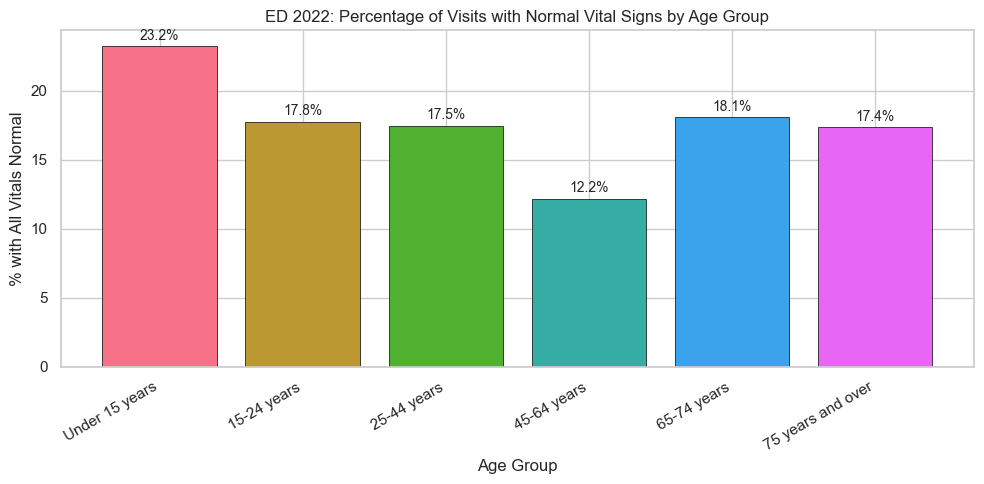

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    summary["Age Group"],
    summary["% Normal Vitals"],
    color=sns.color_palette("husl", 6),
    edgecolor="black",
    linewidth=0.5,
)
ax.set_ylabel("% with All Vitals Normal")
ax.set_xlabel("Age Group")
ax.set_title("ED 2022: Percentage of Visits with Normal Vital Signs by Age Group")
ax.set_xticklabels(summary["Age Group"], rotation=30, ha="right")
for b, pct in zip(bars, summary["% Normal Vitals"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5, f"{pct:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Count of Normal vs Non-Normal by Age Group

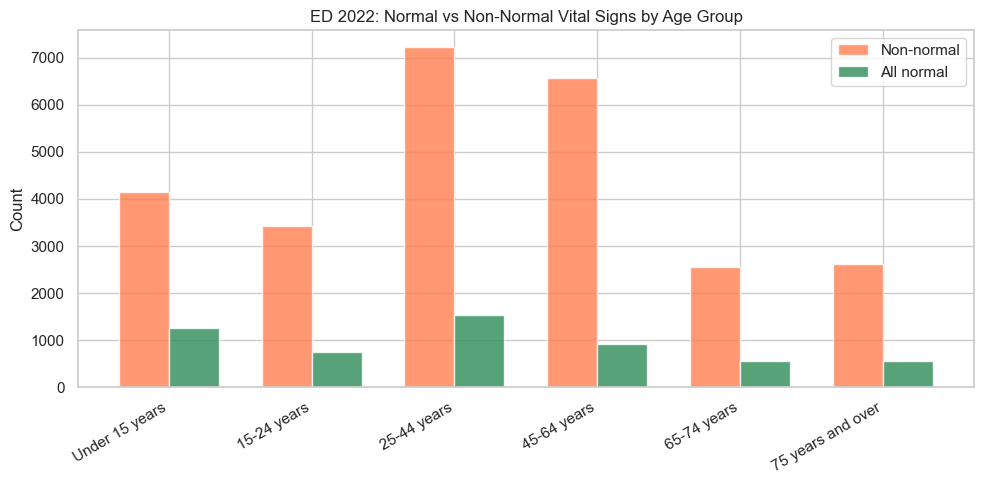

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w / 2, summary["Total Visits"] - summary["Normal Vitals Count"], w, label="Non-normal", color="coral", alpha=0.8)
ax.bar(x + w / 2, summary["Normal Vitals Count"], w, label="All normal", color="seagreen", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(summary["Age Group"], rotation=30, ha="right")
ax.set_ylabel("Count")
ax.set_title("ED 2022: Normal vs Non-Normal Vital Signs by Age Group")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Correlation & Association Analysis: Predictors of ADMIT == 1

Analyzes **correlation** (numeric) and **association** (categorical) of each column with the outcome `ADMIT == 1` (not admitted). Includes logistic regression for predictive strength.

**Note:** Correlation/association ≠ causation. Observational data cannot establish causality; these results show statistical associations only.

In [49]:
# Outcome: ADMIT == 1 (not admitted)
df["ADMIT_1"] = (pd.to_numeric(df["ADMIT"], errors="coerce") == 1).astype(int)
# Apply normal vital signs filter (requires all_normal from Section 2)
df_admit = df[(df["all_normal"] == True) & (df["AGER"].isin([1, 2, 3, 4, 5, 6]))].copy()

# Keep only specified columns (map user names to dataset names where they differ)
keep_cols_raw = [
    "VMONTH", "VDAYR", "ARRTIME", "AGE", "AGER", "AGEDAYS", "SEX", "ETHUN", "ETHIM", "RACEUN", "RACER", "RACERETH", "RESIDNCE",
    "ARREMS", "AMBTRANSFER", "NOPAY", "PAYPRIV", "PAYMCARE", "PAYMCAID", "PAYWKCMP", "PAYSELF", "PAYNOCHG", "PAYOTH", "PAYDK", "PAYTYPER",
    "TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT", "IMMEDR", "PAINSCALE",
    "SEEN72", "RFV1", "RFV2", "RFV3", "RFV4", "RFV5", "RFV13D", "RFV23D", "RFV33D", "RFV43D", "RFV53D", "EPISODE",
    "INJURY", "INJPOISAD", "INJURY72", "INTENT15", "INJURY_ENC", "CAUSE1", "CAUSE2", "CAUSE3",
    "NUMCHRON", "TOTCHRON", "HTN", "HYPERLIPID", "CHF", "CAD", "ANGINA", "MIHX", "STROKE",
    "DIABETES", "COPD", "ASTHMA", "CKD", "ESRD", "OSA", "OBESITY", "DEPRESSION",
    "SUBSTABUSE", "ALZHD", "DEMENTIA", "HISTORY",
    "PREGTEST", "PREGNANT", "ALCOHOL", "BAC", "ETOHAB", "DRUGAB", "DMP", "NODISP", "PSYCH", "VIOLENCE",
    "TRIAGE", "DOA"
]
# Map user names to dataset names where they differ
name_map = {"NUMCHRON": "NOCHRON", "HYPERLIPID": "HYPLIPID", "SUBSTABUSE": "SUBSTAB", "TRIAGE": "CATRIAGE", "DIABETES": "DIABTYP1", "DEPRESSION": "DEPRN"}
keep_cols = [name_map.get(c, c) for c in keep_cols_raw]
keep_cols = [c for c in keep_cols if c in df_admit.columns]
df_admit = df_admit[keep_cols + ["ADMIT", "ADMIT_1"]].copy()
print(f"Normal vitals filter: {len(df_admit):,} rows (from {len(df):,} total)")
print(f"ADMIT == 1 (in subset): {df_admit['ADMIT_1'].sum():,} / {len(df_admit):,} ({100*df_admit['ADMIT_1'].mean():.1f}%)")
print(f"Kept {len(keep_cols)} columns for correlation analysis")

# Numeric columns from our keep list (for correlation)
numeric_cols = [c for c in keep_cols if c in df_admit.columns and np.issubdtype(df_admit[c].dtype, np.number)]
# Include object/str cols that can be coerced to numeric
for c in keep_cols:
    if c not in numeric_cols:
        try:
            _ = pd.to_numeric(df_admit[c], errors="coerce")
            numeric_cols.append(c)
        except Exception:
            pass

# 1. Correlation with ADMIT_1
corr_list = []
for col in numeric_cols:
    x = pd.to_numeric(df_admit[col], errors="coerce")
    y = df_admit["ADMIT_1"]
    mask = x.notna() & y.notna() & ~x.isin([-9, -8, -7])
    if mask.sum() < 100:
        continue
    try:
        r, p = stats.pearsonr(x[mask], y[mask])
        corr_list.append({"Column": col, "Correlation": r, "p-value": p})
    except Exception:
        pass
corr_df = pd.DataFrame(corr_list).sort_values("Correlation", key=abs, ascending=False)
corr_numeric = corr_df.set_index("Column")["Correlation"]
cat_cols = [c for c in keep_cols if c in df_admit.columns and c not in numeric_cols]
print("\nTop 30 columns by |correlation| with ADMIT=1:")
display(corr_df.head(30))

# Save CSV with top 30 columns only (+ ADMIT_1 for reference) - normal vitals subset only
top30_cols = corr_df.head(30)["Column"].tolist()
out_path = "/Users/jasonwang/VisualStudio_Projects/Project_RX/ed2021_2022_top30_correlation.csv"
df_out = df_admit[[c for c in top30_cols if c in df_admit.columns] + ["ADMIT_1"]]
df_out.to_csv(out_path, index=False)
print(f"\nSaved {len(df_out):,} rows (normal vitals only) with top 30 correlated columns + ADMIT_1 to {out_path}")

Normal vitals filter: 5,564 rows (from 32,232 total)
ADMIT == 1 (in subset): 59 / 5,564 (1.1%)
Kept 75 columns for correlation analysis

Top 30 columns by |correlation| with ADMIT=1:


/var/folders/gs/88s910y57tjb5dx_52h8hbgc0000gn/T/ipykernel_49941/709541396.py:48: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x[mask], y[mask])


,Column,Correlation,p-value
3,AGER,0.111155,9.157342e-17
2,AGE,0.110661,1.252596e-16
49,TOTCHRON,0.108146,7.121767e-16
51,HYPLIPID,0.093789,2.386753e-12
29,IMMEDR,-0.093480,2.896563e-09
52,CHF,0.087938,5.005257e-11
55,COPD,0.085639,1.570985e-10
48,NOCHRON,-0.082095,8.642167e-10
50,HTN,0.080118,2.170663e-09
26,BPSYS,0.079731,1.680304e-08



Saved 5,564 rows (normal vitals only) with top 30 correlated columns + ADMIT_1 to /Users/jasonwang/VisualStudio_Projects/Project_RX/ed2021_2022_top30_correlation.csv


In [50]:
# 2. Categorical columns: Cramér's V (association with ADMIT_1)
def cramers_v(x, y):
    """Cramér's V for categorical-categorical association. 0=no association, 1=perfect."""
    from scipy.stats import chi2_contingency
    conf = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(conf)
    n = conf.sum().sum()
    min_dim = min(conf.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

cat_assoc = []
for col in cat_cols:
    try:
        # Drop rows with missing/invalid
        mask = df_admit[col].notna() & ~df_admit[col].isin([-9, -8, -7, -7.0, -8.0, -9.0])
        if mask.sum() < 100:
            continue
        v = cramers_v(df_admit.loc[mask, col].astype(str), df_admit.loc[mask, "ADMIT_1"])
        cat_assoc.append({"Column": col, "Cramér's V": v, "Type": "Categorical"})
    except Exception:
        pass

cat_assoc_df = pd.DataFrame(cat_assoc).sort_values("Cramér's V", ascending=False)
print("Top 25 categorical columns by Cramér's V (association with ADMIT=1):")
display(cat_assoc_df.head(25))

KeyError: "Cramér's V"

In [ ]:
# Logistic regression: predictive strength (association ≠ causation)
# Uses top predictors to model P(ADMIT==1)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Build model matrix from top numeric predictors
model_cols = [c for c in corr_numeric.index[:20] if c in df.columns]
X = df[model_cols].copy()
for c in model_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X)
X_imp = pd.DataFrame(X_imp, columns=model_cols, index=df.index)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
y = df["ADMIT_1"]
mask = ~np.isnan(X_scaled).any(axis=1) & y.notna()
X_fit, y_fit = X_scaled[mask], y[mask].values

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_fit, y_fit)
coef_df = pd.DataFrame({"Column": model_cols, "Coefficient": model.coef_[0]})
coef_df["Abs_Coef"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values("Abs_Coef", ascending=False)
print("Logistic regression coefficients (top predictors of ADMIT==1):")
display(coef_df.head(20))

Logistic regression coefficients (top predictors of ADMIT==2):


,Column,Coefficient,Abs_Coef
0,ADMITHOS,2.275507,2.275507
1,RETREFFU,-0.231887,0.231887
5,EMT,0.128174,0.128174
7,IVFLUIDS,0.102617,0.102617
18,XRAY,0.098799,0.098799
4,CENTLINE,0.093626,0.093626
16,COPD,0.084329,0.084329
2,CONSULT,-0.083488,0.083488
9,NUMGIV,-0.074163,0.074163
11,TOTPROC,0.071184,0.071184


### Top Correlations & Associations with ADMIT == 1 (Visualization)

In [51]:
# Combine numeric and categorical associations
_corr_series = corr_numeric["Correlation"] if isinstance(corr_numeric, pd.DataFrame) else corr_numeric
all_assoc = pd.concat([
    _corr_series.rename("Association").to_frame().assign(Type="Numeric (Point-biserial)"),
    cat_assoc_df.set_index("Column")["Cramér's V"].rename("Association").to_frame().assign(Type="Categorical (Cramér's V)"),
])
all_assoc = all_assoc.sort_values("Association", key=abs, ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["steelblue" if t == "Numeric (Point-biserial)" else "coral" for t in all_assoc["Type"]]
ax.barh(all_assoc.index.astype(str)[::-1], all_assoc["Association"][::-1], color=colors[::-1], alpha=0.8)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Association with ADMIT == 1")
ax.set_title("Top 30 Variables Associated with Not Admitted (ADMIT=1)\nCorrelation ≠ Causation")
ax.legend(handles=[
    plt.matplotlib.patches.Patch(color="steelblue", label="Numeric"),
    plt.matplotlib.patches.Patch(color="coral", label="Categorical"),
])
plt.tight_layout()
plt.show()

NameError: name 'cat_assoc_df' is not defined

## 8. XGBoost: Predicting ADMIT == 1 (Not Admitted)

Uses the **top 20 most correlated** numeric attributes (with ADMIT outcome) to train an XGBoost classifier for predicting `ADMIT == 1` (not admitted). Includes train/test split, metrics, and feature importance.

In [26]:
# XGBoost: Predict ADMIT == 1 using top 20 correlated attributes
# Requires: pip install xgboost (if not already installed)
# Uses df_admit, corr_numeric from Section 7

df_admit["ADMIT_1"] = (pd.to_numeric(df_admit["ADMIT"], errors="coerce") == 1).astype(int)
print(f"Target: ADMIT == 1 (not admitted): {df_admit['ADMIT_1'].sum():,} / {len(df_admit):,} ({100*df_admit['ADMIT_1'].mean():.1f}%)")

# Top 20 most correlated attributes (exclude ADMITHOS - circular with outcome)
_top20 = [c for c in corr_numeric.index[:25] if c in df_admit.columns and c != "ADMITHOS"][:20]
print(f"Features: top 20 by |correlation|: {_top20}")

X_xgb = df_admit[_top20].copy()
for c in _top20:
    X_xgb[c] = pd.to_numeric(X_xgb[c], errors="coerce")
X_xgb = SimpleImputer(strategy="median").fit_transform(X_xgb)
y_xgb = df_admit["ADMIT_1"].values

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_xgb, y_xgb, test_size=0.25, random_state=42, stratify=y_xgb)

try:
    import xgboost as xgb
    clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric="logloss")
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    from sklearn.metrics import accuracy_score, roc_auc_score
    acc_val = accuracy_score(y_te, pred)
    auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1]) if (y_te.sum() > 0 and (1 - y_te).sum() > 0) else 0.5
    print(f"\n--- XGBoost Results ---")
    print(f"Validation accuracy: {acc_val:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    imp = pd.DataFrame({"feature": _top20, "importance": clf.feature_importances_}).sort_values("importance", ascending=False)
    print("\nFeature importance:")
    display(imp)
except ImportError:
    print("Install xgboost: pip install xgboost")

Target: ADMIT == 1 (not admitted): 59 / 5,564 (1.1%)
Features: top 20 by |correlation|: ['COPD', 'ARREMS', 'AGE', 'AGER', 'PAYMCARE', 'TOTCHRON', 'HTN', 'RFV4', 'PAYMCAID', 'IMMEDR', 'HYPLIPID', 'CKD', 'NOCHRON', 'AMBTRANSFER', 'VDAYR', 'INTENT15', 'INJURY72', 'BPSYS', 'PAYDK', 'RESPR']


NameError: name 'SimpleImputer' is not defined